In [9]:
pip install geopandas


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install --upgrade nbformat


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install plotly

^C
ERROR: Operation cancelled by user

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import geopandas as gpd
import plotly.express as px
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [15]:
folder_path = "data_raw/shapefiles/historicalstates"
pre_map_df = gpd.read_file(folder_path)
pre_map_df.rename(columns={'STATENAM': 'state'}, inplace=True)

              0          1          2   3   4   5   6   7   8   9   10  11  \
0          State  Total Pop  Slave Pop NaN NaN NaN NaN NaN NaN NaN NaN NaN   
1          Maine      49133        458 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
2  New Hampshire      87802        541 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
3        Vermont      47620         50 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
4  Massachusetts     268627       4822 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
5   Rhode Island      52946       2671 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
6    Connecticut     206701       5885 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
7       New York     210541      21054 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
8     New Jersey     139627      10460 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
9   Pennsylvania     327305       7855 NaN NaN NaN NaN NaN NaN NaN NaN NaN   

   12  13  14  15  16  
0 NaN NaN NaN NaN NaN  
1 NaN NaN NaN NaN NaN  
2 NaN NaN NaN NaN NaN  
3 NaN NaN NaN NaN NaN  
4 NaN NaN NaN NaN NaN

/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_1037/1819848419.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pre_map_df['population'].fillna(0, inplace=True)


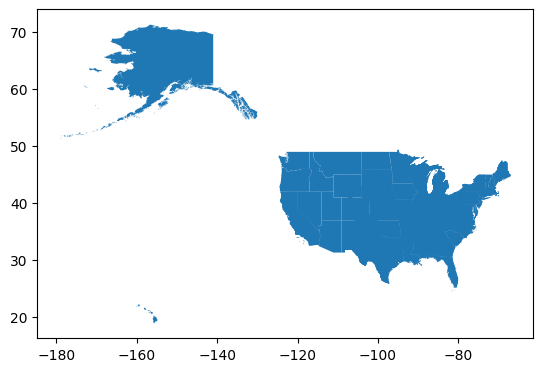

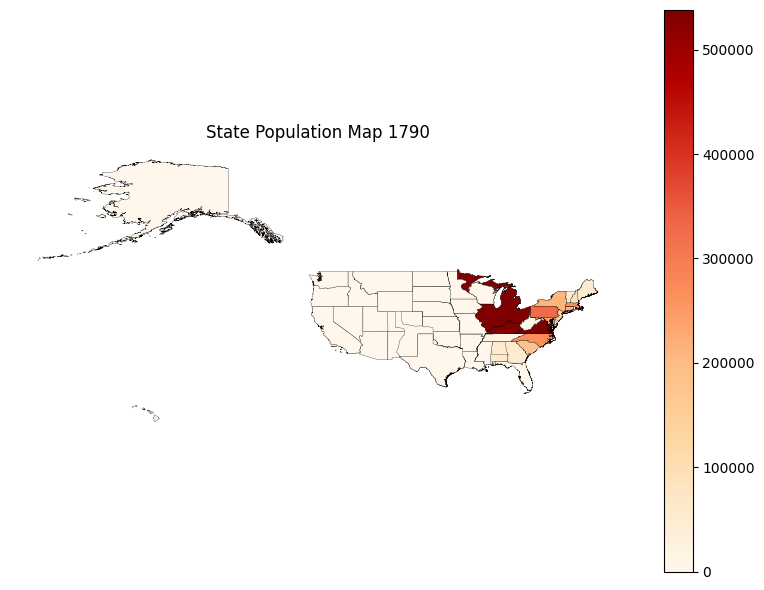

In [19]:
pre_map_df["geometry"] = pre_map_df["geometry"].simplify(0.01).buffer(0)
pre_map_df = pre_map_df.set_crs('EPSG:4326', allow_override=True)

pre_map_df.plot()
for col in pre_map_df.select_dtypes(include='datetime'):
    pre_map_df[col] = pre_map_df[col].astype(str)

pre_map_str = pre_map_df.to_json()

pre_map_gj = json.loads(pre_map_str)

state_pops_raw = pd.read_csv("data_raw/census_data/statePop.csv", header=None)
print(state_pops_raw.head(10))

state_pops = pd.read_csv("data_raw/census_data/statePop.csv", header=0, usecols=[0, 1])
state_pops.columns = ['state', 'population']
state_pops['state'] = state_pops['state'].str.strip().str.title()
state_pops['population'] = pd.to_numeric(state_pops['population'], errors='coerce')
state_pops['state'] = state_pops['state'].str.strip()

pre_map_df['state'] = pre_map_df['FULL_NAME'].str.strip()



valid_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois',
    'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
    'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana',
    'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
    'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
    'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah',
    'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

pre_map_df = pre_map_df[pre_map_df['state'].isin(valid_states)]

pre_map_df.rename(columns={'population': 'old_population'}, inplace=True)

print("Map states:")
print(sorted(pre_map_df['state'].unique()))

print("\nPopulation states:")
state_pops = state_pops[state_pops['state'].notna()]
print(sorted(state_pops['state'].unique()))

pre_map_df['state'] = pre_map_df['FULL_NAME'].str.strip().str.title()

pre_map_df = pre_map_df.merge(
    state_pops[['state', 'population']],
    on='state',
    how='left'
)

missing_population = pre_map_df[pre_map_df['population'].isna()]
if not missing_population.empty:
    print(f"Missing population data for states: {missing_population['state'].tolist()}")
    pre_map_df['population'].fillna(0, inplace=True)  

print(pre_map_df[['state', 'population']].head(10))
print("Missing population values after merge:", pre_map_df['population'].isna().sum())
print("Total states in map:", len(pre_map_df))

print("Missing after merge:", pre_map_df['population'].isna().sum())

pre_map_df['population'] = pd.to_numeric(pre_map_df['population'], errors='coerce')


ax = pre_map_df.plot(
    column='population',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    figsize=(8, 6),
    missing_kwds={
        'color': 'lightgrey',
        'label': 'Missing population data',
        'hatch': '///'
    }
)
ax.set_aspect('equal')
plt.title("State Population Map 1790")
plt.axis('off')
plt.tight_layout()
plt.show()


/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_1037/1416611594.py:1: DtypeWarning: Columns (1,10,12,13,17,18,23,30) have mixed types. Specify dtype option on import or set low_memory=False.
  pre_debt_by_state = pd.read_csv("cleaning_CD/pre1790/data/agg_debt_david.csv")[["state", "amount | dollars"]]


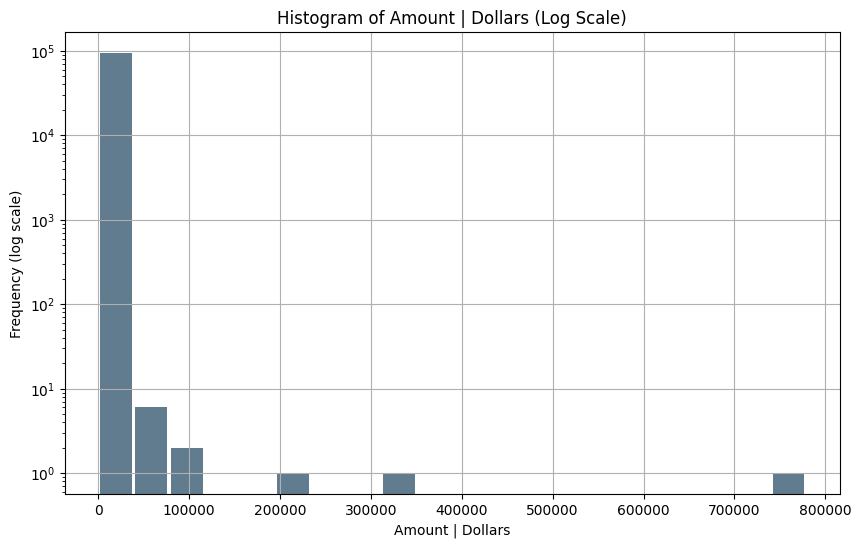

(array([10301]),)


/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_1037/1416611594.py:19: DtypeWarning: Columns (1,10,12,13,17,18,23,30) have mixed types. Specify dtype option on import or set low_memory=False.
  pre_debt_by_state_full = pd.read_csv("cleaning_CD/pre1790/data/agg_debt_david.csv")[["state", "amount | dollars"]]


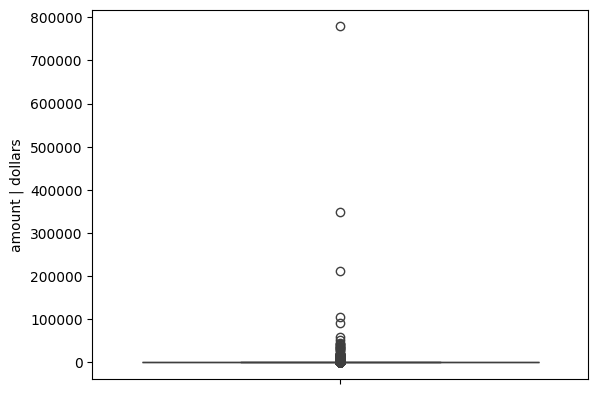

In [20]:
pre_debt_by_state = pd.read_csv("cleaning_CD/pre1790/data/agg_debt_david.csv")[["state", "amount | dollars"]]
pre_debt_by_state["amount | dollars"] = pd.to_numeric(pre_debt_by_state["amount | dollars"], errors="coerce")

filtered_debt = pre_debt_by_state[
    pre_debt_by_state["amount | dollars"].between(
        pre_debt_by_state["amount | dollars"].quantile(0.15),
        pre_debt_by_state["amount | dollars"].quantile(0.85)
    )
]

plt.figure(figsize=(10,6))
pre_debt_by_state["amount | dollars"].plot.hist(bins=20, grid=True, rwidth=0.9, color="#607c8e", log=True)
plt.title("Histogram of Amount | Dollars (Log Scale)")
plt.xlabel("Amount | Dollars")
plt.ylabel("Frequency (log scale)")
plt.show()

#OUTLIERS:
pre_debt_by_state_full = pd.read_csv("cleaning_CD/pre1790/data/agg_debt_david.csv")[["state", "amount | dollars"]]
pre_debt_by_state.columns = pre_debt_by_state.columns
pre_debt_by_state.columns = ["state", "amount | dollars"]
pre_debt_by_state["amount | dollars"]
sns.boxplot(pre_debt_by_state["amount | dollars"])
print(np.where(pre_debt_by_state["amount | dollars"]>(0.5 * 1000000)))
